- [Gráfico 1](#gr1): taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


- [Gráfico 2](#gr2): Taxa de utilização de Espaço da Rede: que é quão bem a abordagem está aproveitando o espaço de armazenamento disponível após uma falha na rede. Uma taxa alta indica uma boa utilização dos recursos 

- [Gráfico 3](#gr3): -Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele


- [Gráfico 4](#gr4): - tempo de realocação

### Configuração inicial

Importando bibliotecas necessárias

In [1]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
# import seaborn as sns
#import plotly.graph_objects as go
import numpy as np
#import plotly.io as pio
#import plotly.express as px


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

### Carregamento dos dados

In [2]:
results_flows_directories = glob.glob('../../results/results_flows*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\goku_s_100_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\g_s_50_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\msf_s_50_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\musfico_s_50_p_8_sfc_on_rel_1']

# Gráfico 1 <a id="gr1"></a>

taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


In [11]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        #print(simu_exec_name)
        alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'

        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                simulation_df = simulation_df[simulation_df['success'] != 'None']

                cumulative_sum_success = 0
                cumulative_avg_success = []

                for i, value in enumerate(simulation_df['success']):
                    # Filtra o DataFrame removendo linhas onde a coluna 'success' tem valores None/NaN
                    cumulative_sum_success += int(value)
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                
                simulation_df['success'] = cumulative_avg_success

                recovered_sfcs = simulation_df[simulation_df['sfc_recovered'] != 'None']
                print(recovered_sfcs['sfc_recovered'])
                recovery_rate = recovered_sfcs.mean() * 100

                total_running_sfcs = simulation_df['running_sfcs'].sum()
                #weighted_recovery_rate = (simulation_df['sfc_recovered'] * simulation_df['running_sfcs']).sum() / total_running_sfcs * 100
                print(recovery_rate)
                simulation_df['recovered_rate'] = recovery_rate
                #simulation_df['weighted_recovery_rate'] = weighted_recovery_rate

                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                log_simu[alg_name]['simulacoes_sucesso'] = log_simu[alg_name]['simulacoes_sucesso'] + 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [12]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed"
]


In [13]:
aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

1070    1
1071    1
Name: sfc_recovered, dtype: object
number_of_sfc             400.000000
cpu_utilization            42.905000
bandwidth_utilization       3.505000
cache_utilization          31.500000
latency                   550.000000
duration                    0.029004
success                    87.068325
crash_moment              100.000000
recovery_time              21.637750
sfc_recovered             550.000000
running_sfcs             3350.000000
running_players          1700.000000
running_sessions          400.000000
server_crashed              0.000000
users_crashed             900.000000
dtype: float64
1066    1
1067    1
1068    1
1069    1
1070    1
1071    1
Name: sfc_recovered, dtype: object
number_of_sfc            4.000000e+02
cpu_utilization          6.129167e+01
bandwidth_utilization    5.518333e+00
cache_utilization        4.650000e+01
latency                  5.550000e+03
duration                 3.846486e-02
success                  8.852090e+01
crash_moment  

In [6]:
boxplot_df = aggregated_simulation_data.groupby(['algorithm','simulation']).mean().reset_index()

KeyError: 'algorithm'

In [ ]:
boxplot_df

,algorithm,simulation,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,duration,success,crash_moment,recovery_time,running_sfcs,running_players,running_sessions,server_crashed,users_crashed
0,MSF,0,4.0,0.503563,0.182121,0.364312,0.159952,0.730870,0.491007,0.000000,44.432554,25.058453,4.801259,0.000899,2.946043
1,MSF,1,4.0,0.444204,0.168756,0.355200,0.159659,0.733824,0.458137,0.001301,39.864534,23.097836,4.474130,0.000941,2.290687
2,MSF,2,4.0,0.470578,0.176337,0.399526,0.160243,0.721716,0.506494,0.013530,40.521212,23.780952,4.884848,0.000866,9.623377
3,MSF,3,4.0,0.509398,0.188385,0.418576,0.162633,0.746727,0.493739,0.003814,45.719141,26.944544,5.303220,0.000894,4.937388
4,MSF,4,4.0,0.535766,0.188462,0.406006,0.159747,0.745418,0.499563,0.002710,46.224847,26.496063,5.257218,0.000875,3.496938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,OSCIM,24,4.0,0.778612,0.199340,0.640425,0.001103,0.872322,0.470730,0.000000,66.285485,37.031275,5.988773,0.000000,1.882919
85,OSCIM,25,4.0,0.788282,0.195089,0.649639,0.001060,0.890144,0.491308,0.012071,66.271353,36.772487,6.083900,0.000000,5.404384
86,OSCIM,26,4.0,0.775132,0.192902,0.616808,0.001059,0.877093,0.521208,0.000214,65.773544,36.056794,5.886413,0.000000,4.690870
87,OSCIM,27,4.0,0.795038,0.207684,0.679161,0.000973,0.892499,0.507474,0.004971,68.541106,38.907324,6.094170,0.000000,5.582212


In [7]:
import seaborn as sns

# Criar um boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='recovered_rate', data=boxplot_df, palette='Set1')

# Estilizar o gráfico
plt.title('Recovered Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Recovered Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovered_rate.pdf')

# Exibir a figura
plt.show()


NameError: name 'boxplot_df' is not defined

<Figure size 1000x600 with 0 Axes>

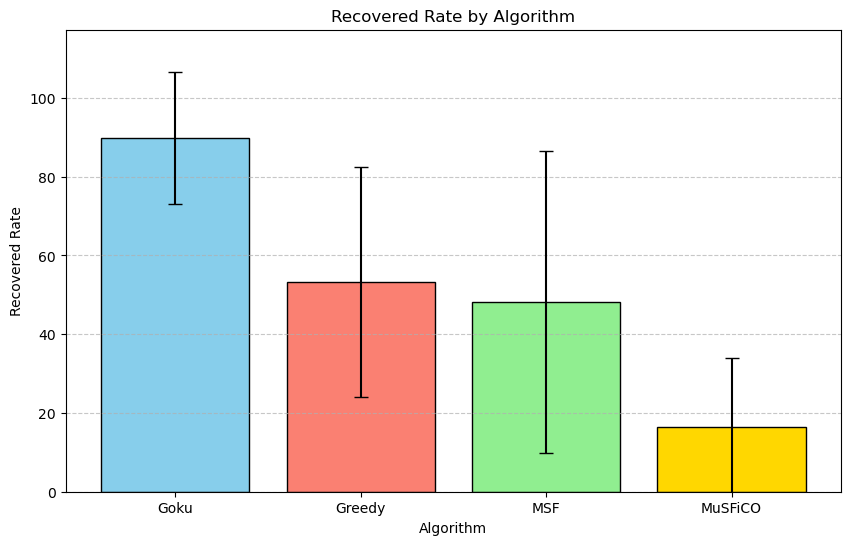

In [38]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de recuperação ponderada por algoritmo
mean_rates = boxplot_df.groupby('algorithm')['recovered_rate'].mean()
std_rates = boxplot_df.groupby('algorithm')['recovered_rate'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_rates.index, mean_rates, yerr=std_rates, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Recovered Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Recovered Rate')
plt.ylim(0, max(mean_rates + std_rates) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovered_rate_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 2 <a id="gr2"></a>

In [39]:
boxplot_df_2 = aggregated_simulation_data.groupby(['algorithm','simulation']).mean().reset_index()

In [40]:
boxplot_df_2['utilization_rate'] = boxplot_df_2[['bandwidth_utilization', 'cpu_utilization', 'cache_utilization']].mean(axis=1)

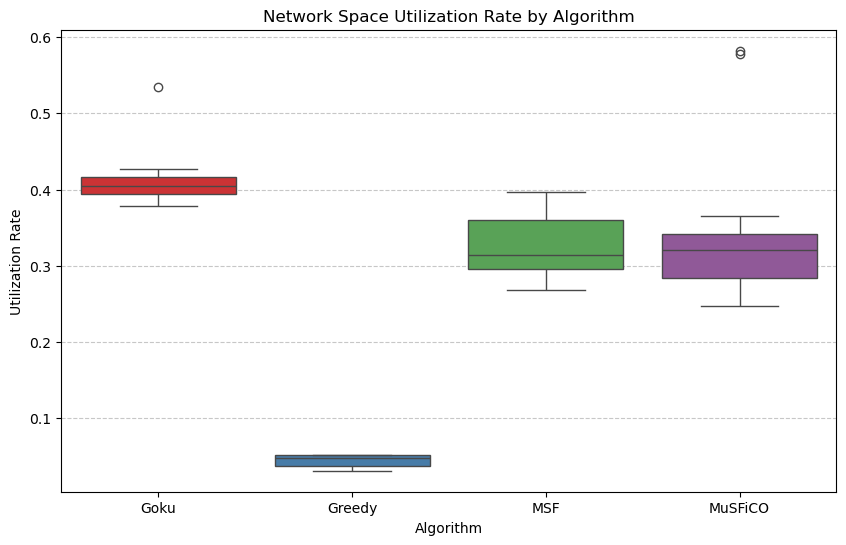

In [41]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='utilization_rate', data=boxplot_df_2, palette='Set1')

# Estilizar o gráfico
plt.title('Network Space Utilization Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Utilization Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('network_utilization_space.pdf')

# Exibir a figura
plt.show()

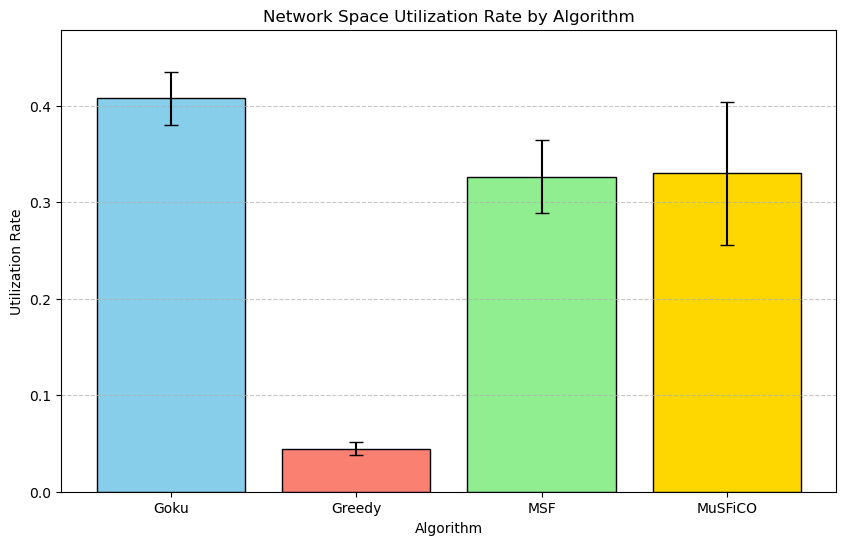

In [42]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de utilização de rede por algoritmo
mean_utilization_rates = boxplot_df_2.groupby('algorithm')['utilization_rate'].mean()
std_utilization_rates = boxplot_df_2.groupby('algorithm')['utilization_rate'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_utilization_rates.index, mean_utilization_rates, yerr=std_utilization_rates, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Network Space Utilization Rate by Algorithm')
plt.xlabel('Algorithm')
plt.ylabel('Utilization Rate')
plt.ylim(0, max(mean_utilization_rates + std_utilization_rates) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('network_utilization_space_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 3 <a id="gr3"></a>

Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele

In [43]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        #print(simu_exec_name)
        alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'Goku'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                
                simulation_df['success'] = cumulative_avg_success
                # Criar a nova coluna com zeros
                
                # Criar a nova coluna com zeros
                simulation_df['latency_diff'] = 0
                simulation_df['benefit_loss_rate'] = 0

                # Filtrar os valores não nulos e diferentes de zero na coluna 'latency'
                valid_latencies = simulation_df['latency'].replace(0, pd.NA).dropna()

                # Definir a latência mínima possível (ideal, sem falha)
                latency_min = valid_latencies.min()

                # Dicionário para armazenar a última latência de cada sfc_id
                last_latency = {}

                # Percorrer o DataFrame para calcular as diferenças de latência e a taxa de perda de benefício
                for index, row in simulation_df.iterrows():
                    sfc_id = row['sfc_id']
                    latency = row['latency']
                    success = row['success']
                    
                    if success:
                        if sfc_id in last_latency:
                            latency_diff = latency - last_latency[sfc_id]
                            simulation_df.at[index, 'latency_diff'] = latency_diff
                            benefit_loss_rate = latency_diff / latency_min
                            simulation_df.at[index, 'benefit_loss_rate'] = benefit_loss_rate
                        last_latency[sfc_id] = latency

                # Calcular ORub como a soma das latências mínimas por sfc_id
                ORub = simulation_df.groupby('sfc_id')['latency'].min().sum()

                # Calcular OR como a soma das latências atuais
                ORe = simulation_df['latency'].sum()
                benefit_loss_rate = (ORub-ORe)/ORub
                simulation_df['benefit_loss_rate_2'] = benefit_loss_rate
                
                simulation_df = simulation_df.dropna()

                #recovered_sfcs = simulation_df['sfc_recovered'].dropna()
                # if alg_name == 'g':
                #     print(recovered_sfcs)
                #     print(file)
                    
                #recovery_rate = recovered_sfcs.mean() * 100

                #simulation_df['recovered_rate'] = recovery_rate
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                log_simu[alg_name]['simulacoes_sucesso'] = log_simu[alg_name]['simulacoes_sucesso'] + 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [44]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id"
]

aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)


Resumo das Simulações:
Algoritmo: Goku
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 0

Algoritmo: Greedy
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 0

Algoritmo: MSF
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 0

Algoritmo: musfico
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 0



In [45]:
aggregated_simulation_data

,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,duration,success,crash_moment,recovery_time,sfc_recovered,...,running_players,running_sessions,server_crashed,users_crashed,sfc_id,latency_diff,benefit_loss_rate,benefit_loss_rate_2,algorithm,simulation
697,4,0.6018,0.1962,0.4545,2.0,0.000508,0.932665,1,0.469759,1.0,...,38,6,0,6,sfc_unique_p7_24,0.0,0.0,-1.709877,Goku,0
698,4,0.6158,0.1993,0.4545,2.0,0.000316,0.932761,1,0.598919,1.0,...,38,6,0,6,sfc_unique_p3_24,0.0,0.0,-1.709877,Goku,0
701,4,0.6355,0.2084,0.4773,4.0,0.000456,0.933048,1,1.029270,1.0,...,39,6,0,6,sfc_unique_p6_24,2.0,2.0,-1.709877,Goku,0
702,4,0.6412,0.2114,0.5000,4.0,0.000444,0.933144,1,1.172092,1.0,...,39,6,0,6,sfc_cache_p6_24,2.0,2.0,-1.709877,Goku,0
703,4,0.6552,0.2195,0.5000,4.0,0.000479,0.933239,1,1.414957,1.0,...,39,6,0,6,sfc_unique_p4_24,2.0,2.0,-1.709877,Goku,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,4,0.4739,0.1878,0.2727,3.0,0.186862,0.821053,1,4.330083,1.0,...,27,5,0,8,sfc_unique_p7_22,2.0,2.0,-1.157588,musfico,26
665,4,0.4752,0.1910,0.2727,3.0,0.164595,0.821321,1,4.690710,1.0,...,27,5,0,8,sfc_cache_p8_22,2.0,2.0,-1.157588,musfico,26
680,4,0.1930,0.0669,0.1591,4.0,0.158688,0.812041,1,0.416389,1.0,...,14,5,0,16,sfc_unique_p5_24,2.0,2.0,-1.385034,musfico,27
688,4,0.2000,0.0699,0.1818,4.0,0.119201,0.804064,1,2.825565,1.0,...,15,5,0,16,sfc_cache_p3_24,2.0,2.0,-1.385034,musfico,27


In [46]:
grouped_df_3 = aggregated_simulation_data.groupby(['algorithm','simulation']).mean(numeric_only=True)

In [47]:
grouped_df_3['Relocation Cost2'] = ((grouped_df_3['benefit_loss_rate_2'] - grouped_df_3['benefit_loss_rate_2'].min()) / (grouped_df_3['benefit_loss_rate_2'].max() - grouped_df_3['benefit_loss_rate_2'].min()))*100

In [48]:
grouped_df_3['Relocation Cost'] = ((grouped_df_3['latency_diff'] - grouped_df_3['latency_diff'].min()) / (grouped_df_3['latency_diff'].max() - grouped_df_3['latency_diff'].min()))*100

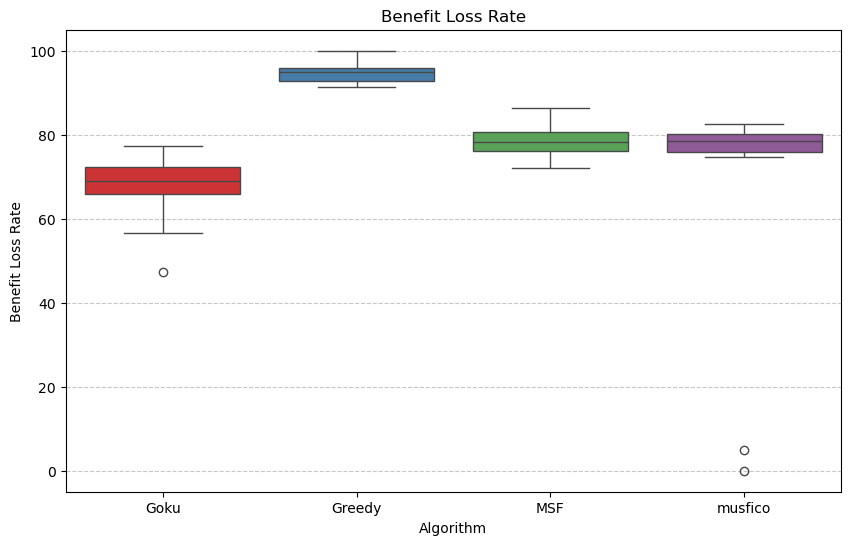

In [49]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='Relocation Cost2', data=grouped_df_3, palette='Set1')

# Estilizar o gráfico
plt.title('Benefit Loss Rate')
plt.xlabel('Algorithm')
plt.ylabel('Benefit Loss Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Benefit_Loss_Rate.pdf')

# Exibir a figura
plt.show()

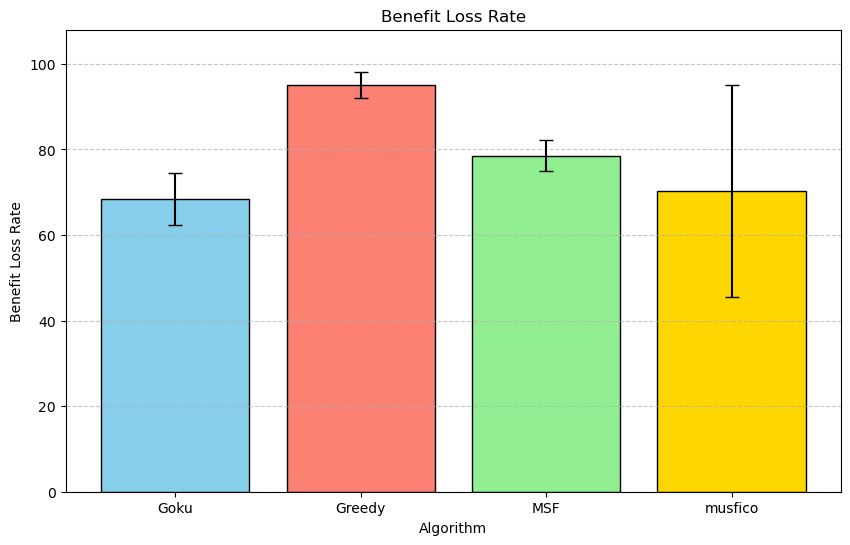

In [50]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos custos de relocação por algoritmo
mean_relocation_cost = grouped_df_3.groupby('algorithm')['Relocation Cost2'].mean()
std_relocation_cost = grouped_df_3.groupby('algorithm')['Relocation Cost2'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_relocation_cost.index, mean_relocation_cost, yerr=std_relocation_cost, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Benefit Loss Rate')
plt.xlabel('Algorithm')
plt.ylabel('Benefit Loss Rate')
plt.ylim(0, max(mean_relocation_cost + std_relocation_cost) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Benefit_Loss_Rate_barplot.pdf')

# Exibir a figura
plt.show()


# Gráfico 4 <a id="gr4"></a>

In [51]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        #print(simu_exec_name)
        alg_name = simu_exec_name[1].split(f'\\')[1]
        reliability = simu_exec_name[-1]
        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'Goku'
        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'reliability': [reliability], 'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:
            log_simu[alg_name]['reliability'].append(reliability)
            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            #print(simulation_is_success)
            if simulation_is_success: 
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df['success']):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                
                simulation_df['success'] = cumulative_avg_success
                execution_time = simulation_df['duration'].mean()
                simulation_df = simulation_df[simulation_df['recovery_time'] != 0]
                for i in simulation_df['recovery_time']:
                    print(i)
                recovery_mean = simulation_df['recovery_time'].mean()
                running_sfcs_mean = simulation_df['running_sfcs'].mean()
                recovery_time_per_sfc = recovery_mean/running_sfcs_mean if running_sfcs_mean != 0  else 0  
                
                if recovery_time_per_sfc == 0 :
                    continue

                simulation_df['recovery_time_per_sfc'] = recovery_time_per_sfc
                simulation_df['recovery_time'] = recovery_mean
                simulation_df['execution_time'] = execution_time
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                log_simu[alg_name]['simulacoes_sucesso'] = log_simu[alg_name]['simulacoes_sucesso'] + 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [52]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id"
]

aggregated_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

0.0771629810333252
0.1173946857452392
0.1579728126525879
0.1993863582611084
0.2410180568695068
0.3347513675689697
0.3771455287933349
0.4200305938720703
0.4631836414337158
0.510350227355957
0.5544466972351074
0.5992398262023926
0.6439030170440674
0.6888623237609863
0.7337656021118164
0.779238224029541
0.8249971866607666
0.8718814849853516
1.0244297981262207
1.4643635749816897
1.519960880279541
1.5721278190612793
1.6225523948669434
1.7012004852294922
0.0914287567138671
0.1384406089782714
0.1849379539489746
0.2318267822265625
0.279374361038208
0.3277528285980224
0.3759458065032959
0.4241418838500976
0.4726607799530029
0.5215699672698975
0.5707664489746094
0.7071504592895508
1.0705897808074951
1.1225314140319824
1.174422264099121
1.2265257835388184
1.2795944213867188
1.3346753120422363
1.390705108642578
1.4457709789276123
1.5361852645874023
2.116160154342652
2.186962604522705
2.2609610557556152
2.341583013534546
2.420837640762329
2.5384552478790283
0.1057546138763427
0.1473791599273681
0.1

In [ ]:
aggregated_simulation_data

,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,duration,success,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,server_crashed,users_crashed,sfc_id,recovery_time_per_sfc,execution_time,algorithm,simulation
359,4,0.3842,0.0754,0.2273,0.0,0.000133,0.888889,1,0.729140,1.0,49,28,5,0,14,sfc_cache_p7_10,0.012135,0.000445,Goku,0
360,4,0.3855,0.0754,0.2273,0.0,0.000131,0.889197,1,0.729140,1.0,50,29,5,0,14,sfc_cache_p8_10,0.012135,0.000445,Goku,0
361,4,0.3867,0.0754,0.2273,0.0,0.000136,0.889503,1,0.729140,1.0,51,30,5,0,14,sfc_cache_p6_10,0.012135,0.000445,Goku,0
362,4,0.3879,0.0754,0.2273,0.0,0.000168,0.889807,1,0.729140,1.0,52,31,5,0,14,sfc_cache_p2_10,0.012135,0.000445,Goku,0
363,4,0.4018,0.0754,0.2273,0.0,0.000126,0.890110,1,0.729140,1.0,53,31,5,0,14,sfc_unique_p2_10,0.012135,0.000445,Goku,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,4,0.3864,0.1487,0.2500,5.0,0.051915,0.835509,1,0.205255,1.0,46,25,5,0,10,sfc_cache_p1_15,0.004462,0.057927,musfico,14
396,4,0.4164,0.1501,0.2273,3.0,0.049350,0.813602,1,0.609679,1.0,44,27,6,0,7,sfc_unique_p7_12,0.013856,0.059955,musfico,16
380,4,0.3864,0.1487,0.2500,5.0,0.075975,0.834646,1,0.269910,1.0,46,25,5,0,10,sfc_cache_p1_15,0.005868,0.058943,musfico,17
383,4,0.4352,0.1875,0.2727,1.0,0.075824,0.833333,1,0.396446,1.0,50,26,6,0,7,sfc_cache_p7_12,0.007929,0.058428,musfico,18


In [ ]:
grouped_df_4 = aggregated_simulation_data[aggregated_simulation_data['recovery_time'] != 0].groupby(['algorithm','simulation']).mean(numeric_only=True).reset_index()

In [ ]:
grouped_df_4

,algorithm,simulation,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,duration,success,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,server_crashed,users_crashed,recovery_time_per_sfc,execution_time
0,Goku,0,4.0,0.458437,0.082954,0.257588,0.333333,0.000159,0.892741,1.0,0.729140,1.0,60.083333,36.250000,5.750000,0.0,14.0,0.012135,0.000445
1,Goku,1,4.0,0.451833,0.133044,0.323241,1.333333,0.000172,0.890671,1.0,1.102665,1.0,56.703704,34.333333,5.814815,0.0,16.0,0.019446,0.000449
2,Goku,2,4.0,0.458190,0.095575,0.300040,0.650000,0.000162,0.883942,1.0,0.761165,1.0,55.950000,32.000000,5.500000,0.0,11.0,0.013604,0.000397
3,Goku,3,4.0,0.440994,0.152012,0.321019,1.687500,0.000195,0.872693,1.0,0.671567,1.0,58.500000,36.750000,6.000000,0.0,12.0,0.011480,0.000459
4,Goku,4,4.0,0.552733,0.183050,0.295500,1.666667,0.000321,0.897651,1.0,0.365565,1.0,70.500000,40.333333,6.000000,0.0,5.0,0.005185,0.000451
5,Goku,5,4.0,0.513212,0.128950,0.282681,1.562500,0.000319,0.892410,1.0,0.879786,1.0,62.437500,36.875000,6.000000,0.0,8.0,0.014091,0.000385
6,Goku,6,4.0,0.475318,0.199718,0.396709,1.454545,0.000316,0.883407,1.0,1.025398,1.0,61.545455,38.818182,6.000000,0.0,7.0,0.016661,0.000407
7,Goku,7,4.0,0.486560,0.122750,0.340900,2.200000,0.000280,0.896786,1.0,0.511294,1.0,64.500000,40.000000,6.000000,0.0,6.0,0.007927,0.000345
8,Goku,8,4.0,0.493800,0.177200,0.329550,1.750000,0.001214,0.890921,1.0,0.482676,1.0,65.500000,39.500000,6.000000,0.0,6.0,0.007369,0.000467
9,Goku,9,4.0,0.548271,0.189257,0.269486,1.857143,0.000267,0.904078,1.0,0.803176,1.0,67.500000,37.142857,6.000000,0.0,9.0,0.011899,0.000471


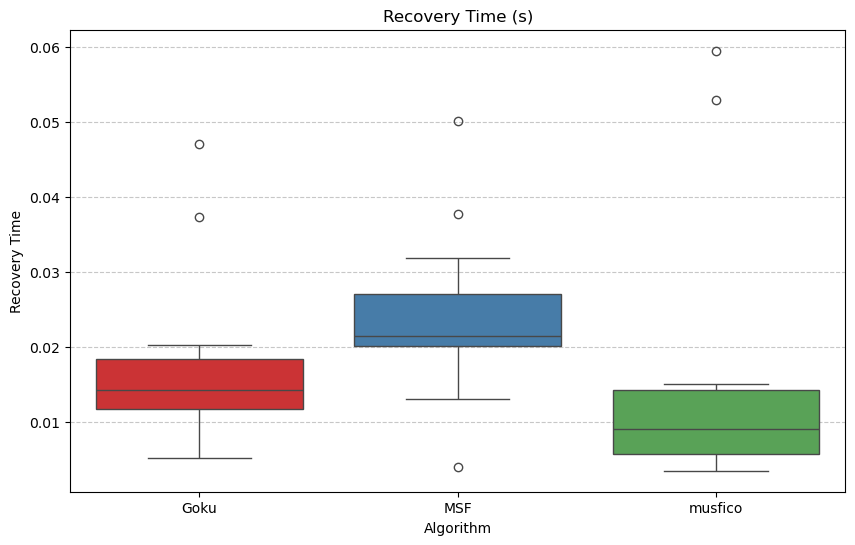

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='recovery_time_per_sfc', data=grouped_df_4, palette='Set1')

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time.pdf')

# Exibir a figura
plt.show()

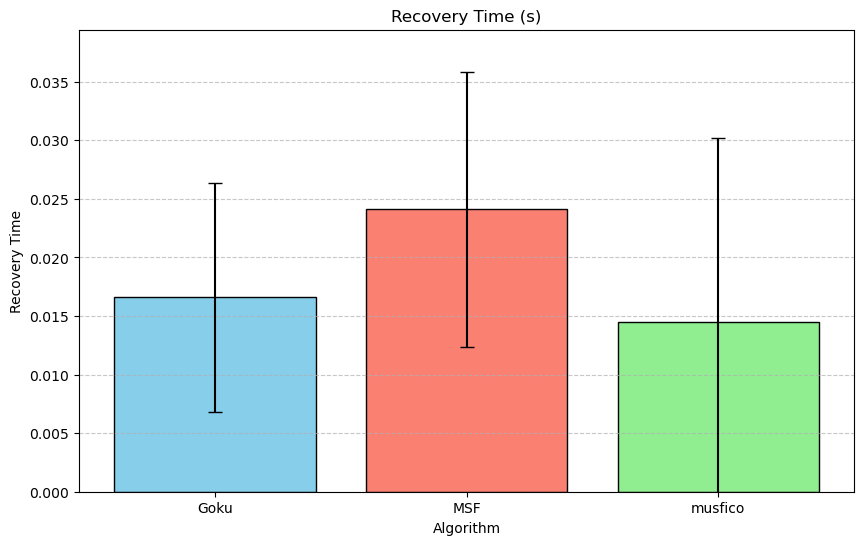

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = grouped_df_4.groupby('algorithm')['recovery_time_per_sfc'].mean()
std_times = grouped_df_4.groupby('algorithm')['recovery_time_per_sfc'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_times.index, mean_times, yerr=std_times, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Recovery Time (s)')
plt.xlabel('Algorithm')
plt.ylabel('Recovery Time')
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('recovery_time_barplot.pdf')

# Exibir a figura
plt.show()

# Gráfico 5

In [ ]:
boxplot_df['success'] = boxplot_df['success']*100

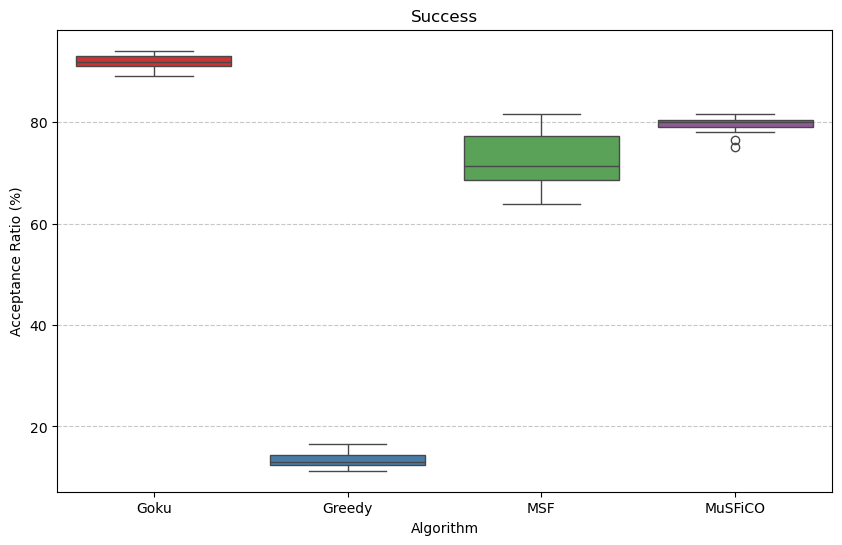

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='algorithm', y='success', data=boxplot_df, palette='Set1')

# Estilizar o gráfico
plt.title('Success')
plt.xlabel('Algorithm')
plt.ylabel('Acceptance Ratio (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Acceptance.pdf')

# Exibir a figura
plt.show()

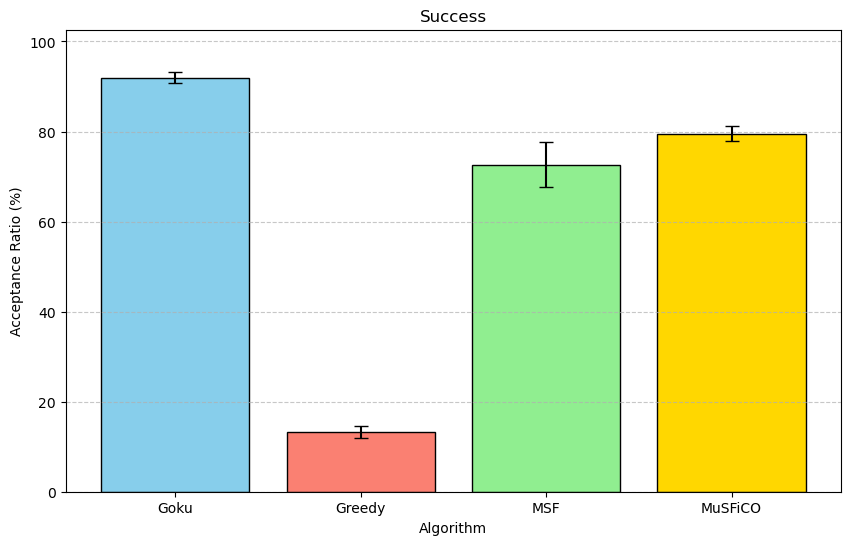

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de sucesso por algoritmo
mean_success = boxplot_df.groupby('algorithm')['success'].mean()
std_success = boxplot_df.groupby('algorithm')['success'].std()

# Definir cores diferentes para cada algoritmo
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum', 'lightcoral']

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_success.index, mean_success, yerr=std_success, capsize=5, color=colors, edgecolor='black')

# Estilizar o gráfico
plt.title('Success')
plt.xlabel('Algorithm')
plt.ylabel('Acceptance Ratio (%)')
plt.ylim(0, max(mean_success + std_success) * 1.1)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a figura
plt.savefig('Acceptance_barplot.pdf')

# Exibir a figura
plt.show()
